In [2]:
import requests
import pandas as pd
import time

print("Initiating API Pagination Engine...")

all_breweries = []
target_pages = 10 

for page in range(1, target_pages + 1):
    
    url = f"https://api.openbrewerydb.org/v1/breweries?per_page=200&page={page}"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        
        
        if not data:
            print(f"Reached the end of the data at page {page}.")
            break
            
        all_breweries.extend(data)
        print(f"✅ Successfully extracted page {page} ({len(data)} records)")
        
        
        time.sleep(0.2)
    else:
        print(f"❌ Error on page {page}: Status Code {response.status_code}")
        break

df_raw = pd.DataFrame(all_breweries)


print(f"Total Breweries Loaded: {len(df_raw)}")
print("\nData Preview:")
print(df_raw[['name', 'brewery_type', 'city', 'state_province']].head())

Initiating API Pagination Engine...
✅ Successfully extracted page 1 (200 records)
✅ Successfully extracted page 2 (200 records)
✅ Successfully extracted page 3 (200 records)
✅ Successfully extracted page 4 (200 records)
✅ Successfully extracted page 5 (200 records)
✅ Successfully extracted page 6 (200 records)
✅ Successfully extracted page 7 (200 records)
✅ Successfully extracted page 8 (200 records)
✅ Successfully extracted page 9 (200 records)
✅ Successfully extracted page 10 (200 records)
Total Breweries Loaded: 2000

Data Preview:
                      name brewery_type            city state_province
0         (405) Brewing Co        micro          Norman       Oklahoma
1         (512) Brewing Co        micro          Austin          Texas
2  1 of Us Brewing Company        micro  Mount Pleasant      Wisconsin
3     10 Barrel Brewing Co        large            Bend         Oregon
4     10 Barrel Brewing Co        large            Bend         Oregon


In [3]:
# Clean Data
df_clean = df_raw.dropna(subset=['state_province', 'city']).copy()

# Filter for Active Businesses Only
valid_types = ['micro', 'regional', 'brewpub', 'large']
df_clean = df_clean[df_clean['brewery_type'].isin(valid_types)]

print(f"✅ Data Cleaned: {len(df_clean)} active target businesses remaining.\n")

# Target States
top_states = df_clean['state_province'].value_counts().reset_index()
top_states.columns = ['State', 'Brewery Count']
top_states = top_states.head(10)

print("Top 5 Target States for Expansion:")
print(top_states.head(5).to_string(index=False))
print("-" * 40)

# Target Cities
top_cities = df_clean.groupby(['state_province', 'city']).size().reset_index(name='Brewery Count')
top_cities = top_cities.sort_values(by='Brewery Count', ascending=False).head(10)

# Rename columns
top_cities.columns = ['State', 'Target City', 'Brewery Count']

print("Top 5 Specific Cities for the New Warehouse:")
print(top_cities.head(5).to_string(index=False))

✅ Data Cleaned: 1720 active target businesses remaining.

Top 5 Target States for Expansion:
     State  Brewery Count
California            156
  Colorado             79
  Michigan             74
  New York             68
     Texas             67
----------------------------------------
Top 5 Specific Cities for the New Warehouse:
     State Target City  Brewery Count
California   San Diego             20
  Colorado      Denver             16
   Ontario     Toronto             16
    Oregon    Portland             15
     Texas     Houston              9


Generating Strategic Expansion Chart...


C:\Users\cashgen\AppData\Local\Temp\ipykernel_20852\2132262842.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


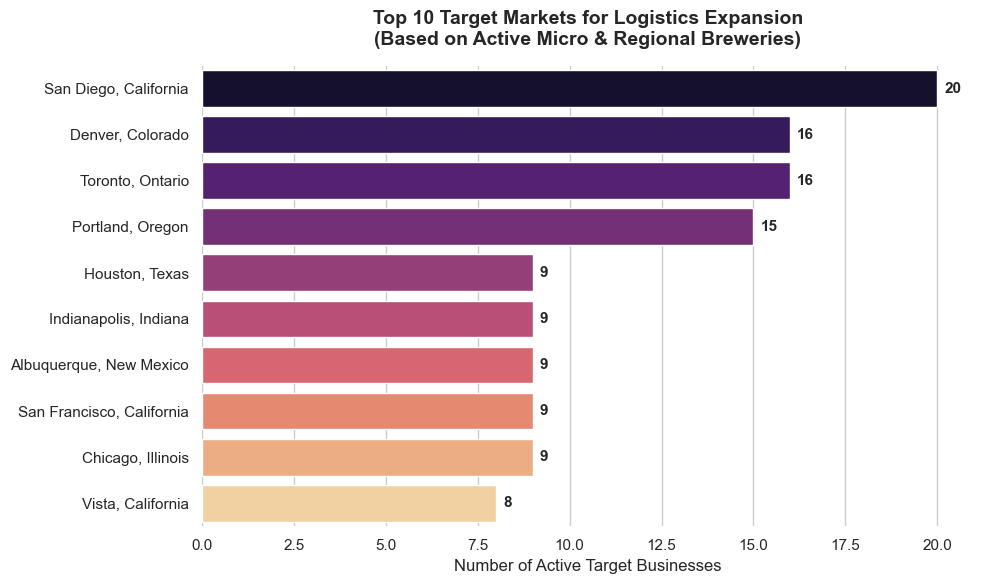

In [4]:
# Plot chart
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Strategic Expansion Chart...")

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

top_cities['Location'] = top_cities['Target City'] + ", " + top_cities['State']

ax = sns.barplot(
    x='Brewery Count',
    y='Location',
    data=top_cities,
    palette="magma" 
)


plt.title("Top 10 Target Markets for Logistics Expansion\n(Based on Active Micro & Regional Breweries)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Active Target Businesses", fontsize=12)
plt.ylabel("") 


for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points',
                fontsize=11, fontweight='bold')


sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()